# Numerical experiment: Standard LQG vs Minimax LQG under privatized measurements

This notebook compares:
1. **Standard LQG** designed for a **nominal Gaussian** measurement-noise model; and  
2. **Minimax LQG** synthesized from the **KL-ball relaxation** (via the risk-sensitive formulation and $\tau^\star$ search).

We then evaluate the empirical finite-horizon quadratic cost under different **actual** measurement-noise distributions (Gaussian and Laplace) with parameters spanning an admissible range.

In [1]:
# %% Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

from numpy.linalg import solve, slogdet


In [2]:
# %% Helper utilities (SPD checks, log-det, norms)
def sym(A):
    return 0.5 * (A + A.T)

def is_pd(A, tol=1e-10):
    # Cholesky-based PD test (with tiny diagonal regularization).
    A = sym(A)
    try:
        np.linalg.cholesky(A + tol*np.eye(A.shape[0]))
        return True
    except np.linalg.LinAlgError:
        return False

def inv_pd(A):
    # Inverse of (assumed) SPD matrix.
    return np.linalg.inv(sym(A))

def logdet_pd(A):
    # log(det(A)) for SPD A (fails otherwise).
    A = sym(A)
    sign, ld = np.linalg.slogdet(A)
    if sign <= 0:
        raise ValueError("Matrix not positive definite for logdet.")
    return ld

def induced_matrix_1norm(C):
    # Induced matrix 1-norm = max column sum.
    return np.max(np.sum(np.abs(C), axis=0))


In [3]:
# %% DP-to-(sigma,b) bounds + eta (from your Proposition 1 and Theorem 1)
def dp_bounds(epsilon, delta, gamma, C):
    '''
    Lower bounds for:
      - Gaussian mechanism variance sigma^2
      - Laplace mechanism scale b

    Adjust this if your manuscript uses a different sensitivity expression.
    '''
    C1 = induced_matrix_1norm(C)
    sigma2 = 2.0 * np.log(1.25/delta) * (C1**2) * (gamma**2) / (epsilon**2)
    b = C1 * gamma / epsilon
    return float(sigma2), float(b)

def g_fun(x, sigma2_nom):
    return np.log(sigma2_nom / x) + x / sigma2_nom

def eta_from_bounds(sigma2_nom, sigma2_ub, b_lb, b_ub, p, N):
    '''
    eta = (L/2) * max{ g(sigma2_ub)-1 ,  max(g(2b_lb^2),g(2 b_ub^2)) - 2 + log(pi) }
    where L = p*(N+1).
    '''
    L = p*(N+1)
    term_gauss = g_fun(sigma2_ub, sigma2_nom) - 1.0
    term_lap = max(g_fun(2*(b_lb**2), sigma2_nom), g_fun(2*(b_ub**2), sigma2_nom)) - 2.0 + np.log(np.pi)
    return float(0.5 * L * max(term_gauss, term_lap))

def kl_gaussian(sigma2_true, sigma2_nom, L):
    # D_KL( N(0,sigma2_true I_L) || N(0,sigma2_nom I_L) ).
    return float(0.5 * L * (g_fun(sigma2_true, sigma2_nom) - 1.0))

def kl_laplace(b_true, sigma2_nom, L):
    # D_KL( Lap(0,b_true)^⊗L || N(0,sigma2_nom I_L) ) using your closed-form bound.
    return float(0.5 * L * (g_fun(2*(b_true**2), sigma2_nom) - 2.0 + np.log(np.pi)))

In [4]:
# %% Problem setup (EDIT ME)

# Dimensions: x in R^n, u in R^m, y in R^p
# Example: discrete-time double integrator
A = np.array([[1.0, 1.0],
              [0.0, 1.0]])
B = np.array([[0.5],
              [1.0]])
C = np.array([[1.0, 0.0]])   # only position measured (before privatization)

n = A.shape[0]
m = B.shape[1]
p = C.shape[0]

# Horizon
N = 10

# Quadratic cost
Q  = np.diag([1.0, 0.1])
R  = np.array([[0.5]])
Qf = 5*Q

# Process noise (Gaussian)
Sigma_w = 1e-3*np.eye(n)

# Initial state distribution x0 ~ N(x_ini, Sigma_ini)
x_ini = np.zeros((n,1))
Sigma_ini = 1e-4*np.eye(n)

# Privacy parameters (EDIT ME)
epsilon = 0.5
delta   = 1e-2

# gamma: sensitivity scaling (EDIT ME; choosing smaller gamma makes noise smaller)
gamma = 0.01

# Upper-bound ratios for admissible parameters (EDIT ME)
ratio_sigma = 1.2
ratio_b     = 1.5

sigma2_nom, b_lb = dp_bounds(epsilon, delta, gamma, C)
sigma2_ub = ratio_sigma * sigma2_nom
b_ub      = ratio_b * b_lb

eta = eta_from_bounds(sigma2_nom, sigma2_ub, b_lb, b_ub, p, N)


print(f"sigma2_nom = {sigma2_nom:.4g}, sigma2_ub = {sigma2_ub:.4g}")
print(f"b_lb       = {b_lb:.4g}, b_ub       = {b_ub:.4g}")
print(f"eta        = {eta:.4g}")


sigma2_nom = 0.003863, sigma2_ub = 0.004635
b_lb       = 0.02, b_ub       = 0.03
eta        = 5.095


In [5]:
# %% Standard finite-horizon LQG (LQR + Kalman predictor)

def design_standard_lqg(A,B,C,Q,R,Qf,Sigma_w,Sigma_ini,sigma2_nom,N):
    '''
    Returns:
      - F[k]  : LQR gain, u_k = -F[k] xhat_k
      - Kf[k] : Kalman predictor gain in the form
               xhat_{k+1} = A xhat_k + B u_k + Kf[k](ytilde_k - C xhat_k)
    '''
    n = A.shape[0]
    p = C.shape[0]
    Rv = sigma2_nom * np.eye(p)

    # --- LQR backward Riccati ---
    P = [None]*(N+1)
    F = [None]*N
    P[N] = Qf.copy()
    for k in range(N-1, -1, -1):
        S = sym(R + B.T @ P[k+1] @ B)
        F[k] = np.linalg.solve(S, B.T @ P[k+1] @ A)  # m x n
        P[k] = sym(Q + A.T @ P[k+1] @ A - A.T @ P[k+1] @ B @ F[k])

    # --- Kalman predictor (time-varying) ---
    Sigma = [None]*(N+1)
    Kf = [None]*N
    Sigma[0] = Sigma_ini.copy()
    for k in range(N):
        S = sym(C @ Sigma[k] @ C.T + Rv)
        Kf[k] = A @ Sigma[k] @ C.T @ inv_pd(S)   # n x p
        Sigma[k+1] = sym(Sigma_w + A @ Sigma[k] @ A.T - Kf[k] @ S @ Kf[k].T)

    return {"F":F, "Kf":Kf, "P":P, "Sigma":Sigma}


In [6]:
# %% Minimax LQG synthesis (risk-sensitive / KL-robust)
#
# Implements the recursion structure from Proposition 2
# and chooses tau* by minimizing tau * (eta + W_tau) over a 1D grid.

def design_minimax_lqg(A,B,C,Q,R,Qf,Sigma_w,Sigma_ini,x_ini,sigma2_nom,eta,N, tau_grid=None, verbose=True, debug=False, return_trace=False):
    n = A.shape[0]
    p = C.shape[0]
    I_n = np.eye(n)
    I_p = np.eye(p)
    R_inv = inv_pd(R)

    # Grid for tau search (EDIT if needed)
    if tau_grid is None:
        tau_grid = np.logspace(-2, 1, 500)

    trace = {"tau": [], "W": [], "obj": [], "feasible": []} if return_trace else None

    best = {"tau": None, "obj": np.inf, "W": None, "seq": None}

    for tau in tau_grid:
        try:
            # --- Forward Riccati (filter side) ---
            Sigma = [None]*(N+1)
            P     = [None]*N
            Pinv  = [None]*N
            K     = [None]*N

            Sigma[0] = Sigma_ini.copy()
            for k in range(N):
                Sigma_inv = inv_pd(Sigma[k])
                Pk = sym(Sigma_inv + (C.T @ C)/sigma2_nom - Q/tau)
                if not is_pd(Pk):
                    raise ValueError("Pk not PD")
                P[k]    = Pk
                Pinv[k] = inv_pd(Pk)
                K[k]    = A @ Pinv[k] @ C.T / sigma2_nom
                Sigma[k+1] = sym(Sigma_w + A @ Pinv[k] @ A.T)

            # --- Backward Riccati (control side) ---
            Pi   = [None]*(N+1)
            Linv = [None]*(N+1)   # Linv[k+1] used in control

            Pi[N] = Qf.copy()
            for k in range(N-1, -1, -1):
                Pi_inv_minus_w = sym(inv_pd(Pi[k+1]) - Sigma_w/tau)
                if not is_pd(Pi_inv_minus_w):
                    raise ValueError("Pi^{-1}-Sigma_w/tau not PD")
                Lk1 = sym(Pi_inv_minus_w + B @ R_inv @ B.T)
                if not is_pd(Lk1):
                    raise ValueError("L_{k+1} not PD")
                Linv[k+1] = inv_pd(Lk1)
                Pi[k] = sym(Q + A.T @ Linv[k+1] @ A)

            # --- Feasibility checks (Gamma set) ---
            for k in range(N+1):
                cond = sym(inv_pd(Pi[k]) - Sigma[k]/tau)
                if not is_pd(cond):
                    raise ValueError("Coupling condition failed")

            # --- Compute W_tau (closed-form expression) ---
            W = 0.0

            # (1) quadratic term in x_ini
            M0 = sym(inv_pd(Pi[0]) - Sigma_ini/tau)
            if not is_pd(M0):
                raise ValueError("M0 not PD")
            W += (1.0/(2*tau)) * (x_ini.T @ inv_pd(M0) @ x_ini).item()

            # (2) determinant terms
            W -= 0.5 * logdet_pd(Sigma_ini)

            for k in range(N):
                Sigma_inv_minus = sym(inv_pd(Sigma[k]) - Q/tau)
                if not is_pd(Sigma_inv_minus):
                    raise ValueError("Sigma^{-1}-Q/tau not PD")

                # log det( Sigma_{k+1} ) + log det( Sigma_k^{-1} - Q/tau )
                W -= 0.5 * (logdet_pd(Sigma[k+1]) + logdet_pd(Sigma_inv_minus))

                middle = sym(sigma2_nom*I_p + C @ inv_pd(Sigma_inv_minus) @ C.T)
                Pi_inv_minus = sym(inv_pd(Pi[k+1]) - Sigma[k+1]/tau)
                if not is_pd(Pi_inv_minus):
                    raise ValueError("Pi^{-1}-Sigma/tau not PD")

                # NOTE: risk-sensitive formulas scale with theta = 1/tau.
                term = K[k] @ middle @ K[k].T @ inv_pd(Pi_inv_minus)
                inner = sym(I_n - term / tau)  # <-- adjust if your final expression differs
                if not is_pd(inner):
                    raise ValueError("Inner logdet term not PD")
                W -= 0.5 * logdet_pd(inner)

            last = sym(inv_pd(Sigma[N]) - Qf/tau)
            if not is_pd(last):
                raise ValueError("Last term not PD")
            W -= 0.5 * logdet_pd(last)

            obj = tau * (eta + W)
            if return_trace:
                trace["tau"].append(float(tau))
                trace["W"].append(float(W))
                trace["obj"].append(float(obj))
                trace["feasible"].append(True)

            if obj < best["obj"]:
                best = {
                    "tau": float(tau),
                    "obj": float(obj),
                    "W": float(W),
                    "seq": {"Sigma":Sigma, "P":P, "Pinv":Pinv, "K":K, "Pi":Pi, "Linv":Linv}
                }

        except Exception as e:
            if debug:
                print("tau", tau, "failed:", type(e).__name__, e)
            if return_trace:
                trace["tau"].append(float(tau))
                trace["W"].append(np.nan)
                trace["obj"].append(np.nan)
                trace["feasible"].append(False)
            continue

    if best["tau"] is None:
        raise RuntimeError("No feasible tau found. Try expanding tau_grid or adjusting parameters.")

    if return_trace:
        best["trace"] = trace

    if verbose:
        print(f"tau* = {best['tau']:.4g},  objective = {best['obj']:.4g},  W_tau = {best['W']:.4g}")
    return best

# Verified against Proposition 2: recursions, W_tau, and estimator/control laws match.
# Added explicit feasibility check Pi^{-1}-Sigma_w/tau per the paper.


Q: [[1.  0. ]
 [0.  0.1]] Qf: [[5.  0. ]
 [0.  0.5]] gamma: 0.01
sigma2_nom: 0.0038626509898418413 eta: 5.094863480838035
eta (fixed by privacy bounds) = 5.09486
tau* (from preview) = 0.122511


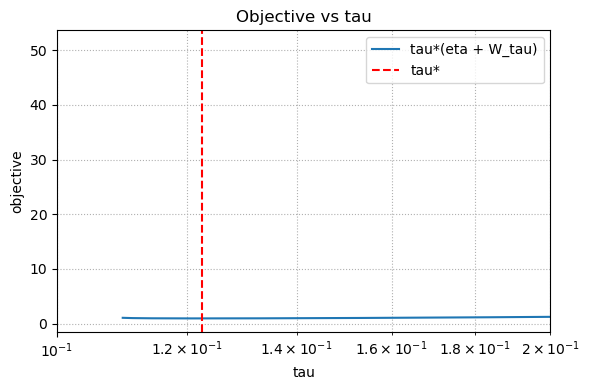

In [8]:
print("Q:", Q, "Qf:", Qf, "gamma:", gamma)
print("sigma2_nom:", sigma2_nom, "eta:", eta)
print(f"eta (fixed by privacy bounds) = {eta:.6g}")

# Plot objective = tau * (eta + W_tau) vs tau (uses default tau grid in design_minimax_lqg)
minimax_preview = design_minimax_lqg(A,B,C,Q,R,Qf,Sigma_w,Sigma_ini,x_ini,sigma2_nom,eta,N,
                                     verbose=False, return_trace=True)
print(f"tau* (from preview) = {minimax_preview['tau']:.6g}")
trace = minimax_preview["trace"]
tau_vals = np.array(trace["tau"])
obj_vals = np.array(trace["obj"])
mask = np.isfinite(obj_vals)

plt.figure(figsize=(6, 4))
plt.semilogx(tau_vals[mask], obj_vals[mask], label="tau*(eta + W_tau)")
plt.axvline(minimax_preview["tau"], color="r", linestyle="--", label="tau*")
plt.xlabel("tau")
plt.ylabel("objective")
plt.title("Objective vs tau")
plt.xlim(1e-1, 2e-1)
plt.grid(True, which="both", ls=":")
plt.legend()
plt.tight_layout()


 


In [58]:
# %% Build both controllers

# Standard LQG
std = design_standard_lqg(A,B,C,Q,R,Qf,Sigma_w,Sigma_ini,sigma2_nom,N)

# Minimax LQG (using the feasible tau grid found)
if "minimax_preview" in globals():
    minimax = minimax_preview
else:
    minimax = design_minimax_lqg(A,B,C,Q,R,Qf,Sigma_w,Sigma_ini,x_ini,sigma2_nom,eta,N,
                                tau_grid=np.logspace(-1, 1, 500), verbose=True)

tau_star = minimax["tau"]
seq = minimax["seq"]


In [59]:
# %% Simulation engine + controllers


class StandardLQGController:
    def __init__(self, A,B,C,F_seq,Kf_seq):
        self.A=A; self.B=B; self.C=C
        self.F=F_seq
        self.Kf=Kf_seq

    def step(self, k, xhat, ytilde):
        u = - self.F[k] @ xhat
        xhat_next = self.A@xhat + self.B@u + self.Kf[k] @ (ytilde - self.C@xhat)
        return u, xhat_next

class MinimaxLQGController:
    def __init__(self, A,B,C,Q,R,seq,tau_star,sigma2_nom):
        self.A=A; self.B=B; self.C=C
        self.Q=Q; self.R=R
        self.seq=seq
        self.tau=tau_star
        self.sigma2=sigma2_nom
        self.R_inv = inv_pd(R)
        self.Pinv = seq["Pinv"]

    def step(self, k, xhat, ytilde):
        Sigma_k = self.seq["Sigma"][k]
        Pi_k    = self.seq["Pi"][k]
        Linv_k1 = self.seq["Linv"][k+1]

        # coupling inverse
        M = sym(np.eye(Sigma_k.shape[0]) - Sigma_k @ Pi_k / self.tau)
        z = np.linalg.solve(M, xhat)

        # u_k = -R^{-1} B^T L_{k+1}^{-1} A (I - Sigma_k Pi_k / tau)^{-1} xhat_k
        u = - self.R_inv @ self.B.T @ Linv_k1 @ self.A @ z

        # risk-sensitive/minimax estimator recursion (Proposition 2)
        Kk = self.seq["K"][k]
        xhat_next = (self.A@xhat + self.B@u
                     + Kk @ (ytilde - self.C@xhat)
                     + self.A @ self.Pinv[k] @ (self.Q/self.tau) @ xhat)
        return u, xhat_next

def simulate_cost(A,B,C,Q,R,Qf,Sigma_w,controller,noise_sampler,N,Sigma_ini,x_ini,num_mc=200,seed=0):
    rng = np.random.default_rng(seed)
    n = A.shape[0]

    costs = np.zeros(num_mc)
    for s in range(num_mc):
        x = rng.multivariate_normal(mean=x_ini.flatten(), cov=Sigma_ini).reshape(n,1)
        xhat = x_ini.copy()

        J = 0.0
        for k in range(N):
            y = C @ x
            v = noise_sampler(rng)           # p x 1
            ytilde = y + v

            u, xhat_next = controller.step(k, xhat, ytilde)

            # stage cost
            J += 0.5 * (x.T@Q@x + u.T@R@u).item()

            # plant update
            w = rng.multivariate_normal(mean=np.zeros(n), cov=Sigma_w).reshape(n,1)
            x = A@x + B@u + w
            xhat = xhat_next

        J += 0.5 * (x.T@Qf@x).item()
        costs[s] = J

    return costs

# Instantiate
std_ctrl = StandardLQGController(A,B,C,std["F"],std["Kf"])
min_ctrl = MinimaxLQGController(A,B,C,Q,R,seq,tau_star,sigma2_nom)

# Noise samplers
def gauss_sampler(sigma2):
    sigma = np.sqrt(sigma2)
    return lambda rng: rng.normal(loc=0.0, scale=sigma, size=(p,1))

def laplace_sampler(b):
    return lambda rng: rng.laplace(loc=0.0, scale=b, size=(p,1))




# Memory-efficient max-cost computation
def simulate_cost_max(A,B,C,Q,R,Qf,Sigma_w,controller,noise_sampler,N,Sigma_ini,x_ini,num_mc=200,seed=0):
    rng = np.random.default_rng(seed)
    n = A.shape[0]

    max_cost = -np.inf
    for s in range(num_mc):
        x = rng.multivariate_normal(mean=x_ini.flatten(), cov=Sigma_ini).reshape(n,1)
        xhat = x_ini.copy()

        J = 0.0
        for k in range(N):
            y = C @ x
            v = noise_sampler(rng)           # p x 1
            ytilde = y + v

            u, xhat_next = controller.step(k, xhat, ytilde)

            # stage cost
            J += 0.5 * (x.T@Q@x + u.T@R@u).item()

            # plant update
            w = rng.multivariate_normal(mean=np.zeros(n), cov=Sigma_w).reshape(n,1)
            x = A@x + B@u + w
            xhat = xhat_next

        J += 0.5 * (x.T@Qf@x).item()
        if J > max_cost:
            max_cost = J

    return max_cost


# Compute mean and 95th percentile cost (per sweep point)
def simulate_cost_stats(A,B,C,Q,R,Qf,Sigma_w,controller,noise_sampler,N,Sigma_ini,x_ini,num_mc=200,seed=0, q=0.99):
    rng = np.random.default_rng(seed)
    n = A.shape[0]

    costs = np.zeros(num_mc)
    max_cost = -np.inf
    for s in range(num_mc):
        x = rng.multivariate_normal(mean=x_ini.flatten(), cov=Sigma_ini).reshape(n,1)
        xhat = x_ini.copy()

        J = 0.0
        for k in range(N):
            y = C @ x
            v = noise_sampler(rng)           # p x 1
            ytilde = y + v

            u, xhat_next = controller.step(k, xhat, ytilde)

            # stage cost
            J += 0.5 * (x.T@Q@x + u.T@R@u).item()

            # plant update
            w = rng.multivariate_normal(mean=np.zeros(n), cov=Sigma_w).reshape(n,1)
            x = A@x + B@u + w
            xhat = xhat_next

        J += 0.5 * (x.T@Qf@x).item()
        costs[s] = J
        if J > max_cost:
            max_cost = J

    return float(costs.mean()), float(np.quantile(costs, q)), float(max_cost)


In [66]:
# %% Compute cost statistics across noise scales (mean and 99th percentile)
num_mc = 500
num_grid = 20  # number of points in each sweep

# Gaussian: sigma^2 from lower bound to upper bound
sigma2_lb = sigma2_nom
sigma2_grid = np.linspace(sigma2_lb, sigma2_ub, num_grid)

J_std_gauss_mean = []
J_std_gauss_q95  = []
J_std_gauss_max  = []
J_min_gauss_mean = []
J_min_gauss_q95  = []
J_min_gauss_max  = []
for i, s2 in enumerate(tqdm(sigma2_grid, desc="Gaussian sweep")):
    sampler = gauss_sampler(s2)
    J_std_mean, J_std_q95, J_std_max = simulate_cost_stats(A,B,C,Q,R,Qf,Sigma_w,std_ctrl,sampler,N,Sigma_ini,x_ini,
                                               num_mc=num_mc, seed=1000 + i)
    J_min_mean, J_min_q95, J_min_max = simulate_cost_stats(A,B,C,Q,R,Qf,Sigma_w,min_ctrl,sampler,N,Sigma_ini,x_ini,
                                               num_mc=num_mc, seed=2000 + i)
    J_std_gauss_mean.append(J_std_mean)
    J_std_gauss_q95.append(J_std_q95)
    J_std_gauss_max.append(J_std_max)
    J_min_gauss_mean.append(J_min_mean)
    J_min_gauss_q95.append(J_min_q95)
    J_min_gauss_max.append(J_min_max)

# Laplace: b from lower bound to upper bound
b_grid = np.linspace(b_lb, b_ub, num_grid)

J_std_lap_mean = []
J_std_lap_q95  = []
J_std_lap_max  = []
J_min_lap_mean = []
J_min_lap_q95  = []
J_min_lap_max  = []
for i, b in enumerate(tqdm(b_grid, desc="Laplace sweep")):
    sampler = laplace_sampler(b)
    J_std_mean, J_std_q95, J_std_max = simulate_cost_stats(A,B,C,Q,R,Qf,Sigma_w,std_ctrl,sampler,N,Sigma_ini,x_ini,
                                               num_mc=num_mc, seed=3000 + i)
    J_min_mean, J_min_q95, J_min_max = simulate_cost_stats(A,B,C,Q,R,Qf,Sigma_w,min_ctrl,sampler,N,Sigma_ini,x_ini,
                                               num_mc=num_mc, seed=4000 + i)
    J_std_lap_mean.append(J_std_mean)
    J_std_lap_q95.append(J_std_q95)
    J_std_lap_max.append(J_std_max)
    J_min_lap_mean.append(J_min_mean)
    J_min_lap_q95.append(J_min_q95)
    J_min_lap_max.append(J_min_max)


Laplace sweep: 100%|██████████| 20/20 [00:11<00:00,  1.71it/s]


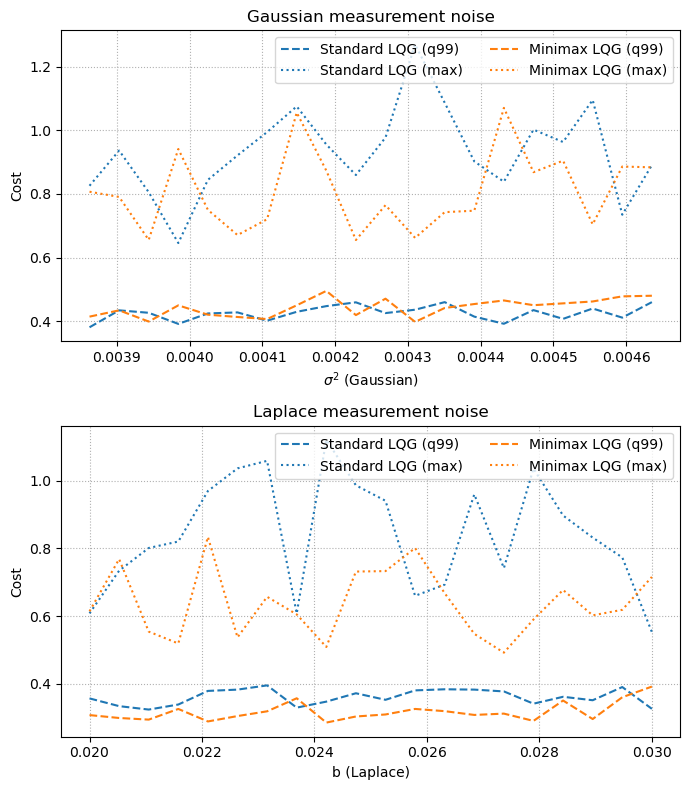

In [67]:
# Plot mean, 99th percentile (q99), and worst-case (max): 2x1 subplots
fig, axes = plt.subplots(2, 1, figsize=(7, 8), sharey=False)

# Gaussian
# axes[0].plot(sigma2_grid, J_std_gauss_mean, label='Standard LQG (mean)', color='C0', linestyle='-')
axes[0].plot(sigma2_grid, J_std_gauss_q95,  label='Standard LQG (q99)', color='C0', linestyle='--')
axes[0].plot(sigma2_grid, J_std_gauss_max,  label='Standard LQG (max)', color='C0', linestyle=':')
# axes[0].plot(sigma2_grid, J_min_gauss_mean, label='Minimax LQG (mean)', color='C1', linestyle='-')
axes[0].plot(sigma2_grid, J_min_gauss_q95,  label='Minimax LQG (q99)', color='C1', linestyle='--')
axes[0].plot(sigma2_grid, J_min_gauss_max,  label='Minimax LQG (max)', color='C1', linestyle=':')
axes[0].set_xlabel(r'$\sigma^2$ (Gaussian)')
axes[0].set_ylabel('Cost')
axes[0].set_title('Gaussian measurement noise')
axes[0].grid(True, ls=':')
axes[0].legend(ncol=2)

# Laplace
# axes[1].plot(b_grid, J_std_lap_mean, label='Standard LQG (mean)', color='C0', linestyle='-')
axes[1].plot(b_grid, J_std_lap_q95,  label='Standard LQG (q99)', color='C0', linestyle='--')
axes[1].plot(b_grid, J_std_lap_max,  label='Standard LQG (max)', color='C0', linestyle=':')
# axes[1].plot(b_grid, J_min_lap_mean, label='Minimax LQG (mean)', color='C1', linestyle='-')
axes[1].plot(b_grid, J_min_lap_q95,  label='Minimax LQG (q99)', color='C1', linestyle='--')
axes[1].plot(b_grid, J_min_lap_max,  label='Minimax LQG (max)', color='C1', linestyle=':')
axes[1].set_xlabel('b (Laplace)')
axes[1].set_ylabel('Cost')
axes[1].set_title('Laplace measurement noise')
axes[1].grid(True, ls=':')
axes[1].legend(ncol=2)

plt.tight_layout()
